Given a function $u = (Id + g_L) \circ\dots\circ (Id+g_1)$, we are looking at the Gram matrix of the tangent space $T_u \mathcal{M}$ defined by $G = (\langle \phi_i, \phi_j \rangle)_{i,j}$, where $T_u \mathcal{M} = \operatorname{span}(\phi_1, \dots, \phi_n)$.

In [1]:
import jax
import jax.numpy as jnp
import jax.random as random
import matplotlib.pyplot as plt
import sys
from jaxtyping import Float, Array, PRNGKeyArray

jax.config.update("jax_enable_x64", True)
sys.path.insert(0, "..")

In [2]:
from ctt.bases import make_canonical_polynomials, make_fourier, make_legendre_polynomials, make_chebyshev_polynomials

d = 3
n_features = 2
basis = make_canonical_polynomials(dim=n_features)
# basis = make_legendre_polynomials(dim=n_features)
# basis = make_chebyshev_polynomials(dim=n_features)
# basis = make_fourier(n_features)
# basis = lambda x: jnp.asarray([1., jax.nn.leaky_relu(x)])
key = random.PRNGKey(42)

In [3]:
from ctt.model import make_ctt

def lift(x: Float[Array, "d"]) -> Float[Array, "m"]:
    # return jnp.hstack((jnp.zeros((1,)), x))
    return x

def retraction(x: Float[Array, "m"]) -> Float[Array, "o"]:
    return jnp.asarray((x[0],))

d_lift = jax.eval_shape(lift, jax.ShapeDtypeStruct((d,), dtype=float)).shape[0]
ctt = make_ctt(lift, retraction, basis, d)

In [72]:
from ctt.tt import validate_ranks, TT
import jax.flatten_util

domain = (0., 1.)
num_steps = 3
rank = 2
ranks = [d_lift] + [rank]*(d_lift-1) + [1]
ranks = validate_ranks([n_features]*d_lift, ranks)

@jax.jit
def get_gramian(params: list[TT], x: Float[Array, "B d"]) -> Float[Array, "n_params n_params"]:
    # f = lambda w: jax.vmap(ctt, in_axes=(None,0))(w, x).ravel() / jnp.sqrt(x.shape[0])
    # J = jax.jacfwd(f)(params)
    # flatten_J, _ = jax.flatten_util.ravel_pytree(J)
    # flatten_J = jnp.reshape(flatten_J, (x.shape[0], -1))
    # G = flatten_J.T @ flatten_J
    # def _g(p, x):
    #     grads = jax.grad(lambda p,x: ctt(p, x)[0])(p, x)
    #     flatten_grads, _ = jax.flatten_util.ravel_pytree(grads)
    #     return flatten_grads
    
    # grads = jax.vmap(_g, in_axes=(None, 0))(params, x)
    # G = grads.T @ grads / x.shape[0]
    # return G
    flat_params, unravel_fn = jax.flatten_util.ravel_pytree(params)

    def _f(p):
        p = unravel_fn(p)
        return jax.vmap(ctt, in_axes=(None, 0))(p, x).ravel()
    
    J = jax.jacfwd(_f)(flat_params) # (n_output, n_params)
    G = J.T @ J / x.shape[0]
    return G

In [84]:
from ctt.tt import tt_randn, tt_rand, tt_orthogonalize
key, *param_keys = random.split(key, num=num_steps+1)
    
def left_orth(tt: TT) -> TT:
    U, V, S = tt_orthogonalize(tt)
    return [S[0]] + V

params_u = [
    # tt_randn(control_key, [n_features] * d_lift, ranks, cov=2)
    tt_rand(control_key, [n_features]*d_lift, ranks)
    for control_key in param_keys
]
params_u = list(map(left_orth, params_u))

In [85]:
from tqdm.notebook import tqdm
nb_sim = 100

N_gram = 10_000
gram_matrices = []
for i in tqdm(range(nb_sim)):
    key, gram_key = random.split(key)
    X_gram = random.uniform(key=gram_key, shape=(N_gram, d), minval=domain[0], maxval=domain[1])
    gram_matrices.append(get_gramian(params_u, X_gram))
    
gram_matrices = jnp.stack(gram_matrices)

  0%|          | 0/100 [00:00<?, ?it/s]

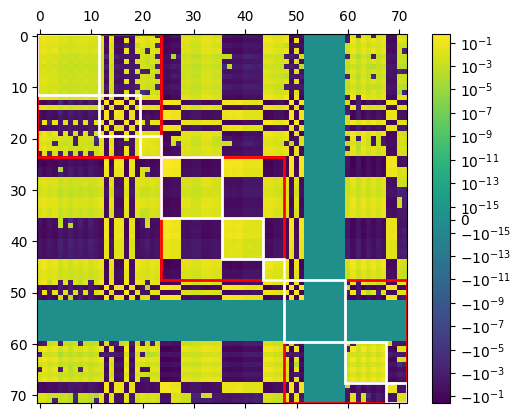

In [115]:
import matplotlib.patches as patches
import matplotlib.colors

def sizeof_pytree(p) -> int:
    leaves = jax.tree.leaves(p)
    return sum(jnp.size(leaf) for leaf in leaves)

fig, ax = plt.subplots()
# plot the Gram matrix
G_hat = jnp.mean(gram_matrices, axis=0)
im = ax.matshow(G_hat, cmap="viridis", norm=matplotlib.colors.SymLogNorm(1e-15))
# draw the block diagonals
pos = 0
for i in range(num_steps):
    size = sizeof_pytree(params_u[i])
    rect = patches.Rectangle((pos-0.5, pos-0.5), size, size, linewidth=2, edgecolor="r", facecolor='none')
    ax.add_patch(rect)
    inner_pos = pos
    for j in range(len(params_u[i])):
        core_size = sizeof_pytree(params_u[i][j])
        rect = patches.Rectangle((inner_pos-0.5, inner_pos-0.5), core_size, core_size, linewidth=2, edgecolor="white", facecolor="none")
        ax.add_patch(rect)
        inner_pos += core_size
    pos += size
ax.set_aspect("equal")
fig.colorbar(im, ax=ax)

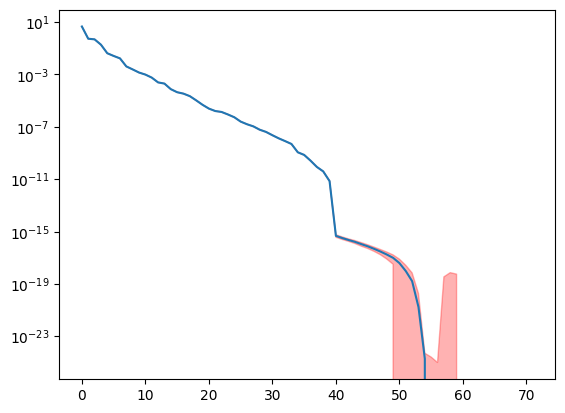

In [116]:
get_ev = lambda A: jnp.linalg.eigh(A)[0]

eigenvalues = jax.vmap(get_ev)(gram_matrices)[:, ::-1]
m = jnp.mean(eigenvalues, axis=0)
std = jnp.std(eigenvalues, axis=0)

plt.semilogy(jnp.arange(len(m)), m)
plt.fill_between(jnp.arange(len(m)), m-std, m+std, color="red", alpha=0.3)

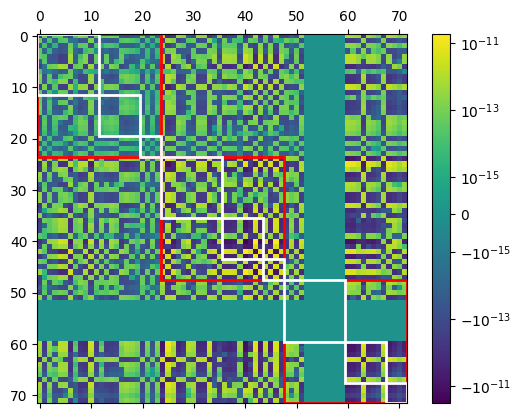

In [117]:
w, v = jnp.linalg.eigh(G_hat)
indices = w > 1e-10
w = w[indices]
v = v[:, indices]

G_hat_trunc = (v*w) @ v.T

fig, ax = plt.subplots()
# plot the Gram matrix
im = ax.matshow(G_hat_trunc-G_hat, cmap="viridis", norm=matplotlib.colors.SymLogNorm(1e-15))
# draw the block diagonals
pos = 0
for i in range(num_steps):
    size = sizeof_pytree(params_u[i])
    rect = patches.Rectangle((pos-0.5, pos-0.5), size, size, linewidth=2, edgecolor="r", facecolor='none')
    ax.add_patch(rect)
    inner_pos = pos
    for j in range(len(params_u[i])):
        core_size = sizeof_pytree(params_u[i][j])
        rect = patches.Rectangle((inner_pos-0.5, inner_pos-0.5), core_size, core_size, linewidth=2, edgecolor="white", facecolor="none")
        ax.add_patch(rect)
        inner_pos += core_size
    pos += size
ax.set_aspect("equal")
fig.colorbar(im, ax=ax)